# Introdución ás redes neuronais — Adestrar MNIST nunha CPU

Benvido/a! Neste caderno imos ensinarlle a un ordenador a **ler díxitos manuscritos**.

Usamos o clásico conxunto de datos **MNIST**: 70.000 imaxes minúsculas (28×28 píxeles)
en escala de grises de díxitos do 0 ao 9. É o «Ola, mundo!» da aprendizaxe automática.

Imos construír e adestrar **dúas** redes neuronais, da máis simple á máis potente:

1. **Un perceptrón (un perceptrón multicapa, MLP)** — o tipo máis sinxelo de rede
   neuronal, no que cada píxel se conecta con cada neurona.
2. **Unha rede neuronal convolucional (CNN)** — unha rede deseñada especificamente para
   imaxes, que mira pequenas rexións e aprende a detectar formas como bordos e curvas.

Todo isto execútase nunha **CPU** normal en un par de minutos — non fai falta GPU.

> **Como usar este caderno:** executa as celas unha a unha, de arriba a abaixo
> (selecciona unha cela e preme `Maiús + Intro`). Le o texto entre as celas de código —
> aí é onde se explican os conceptos.

## 0. Preparación (setup)

Primeiro importamos as bibliotecas que necesitamos:

- **PyTorch** (`torch`) — o marco de traballo que usamos para construír e adestrar redes
  neuronais.
- **torchvision** — proporciónanos o conxunto de datos MNIST e ferramentas para imaxes.
- **matplotlib** — para debuxar imaxes e gráficas.

Tamén fixamos unha *semente aleatoria* para que os resultados sexan reproducibles (obtés
os mesmos números cada vez que o executas), e indicámoslle explicitamente a PyTorch que
use a **CPU**.

In [13]:
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# Reproducibilidade: os mesmos números aleatorios en cada execución
torch.manual_seed(0)

# Adestramos na CPU (non fai falta GPU para este pequeno exemplo)
device = torch.device("cpu")
print("Versión de PyTorch:", torch.__version__)
print("Dispositivo de adestramento:", device)

Versión de PyTorch: 2.8.0
Dispositivo de adestramento: cpu


## 1. Cargar os datos

Un modelo de aprendizaxe automática aprende a partir de **exemplos**. Aquí cada exemplo é:

- unha **entrada**: unha imaxe 28×28 dun díxito, e
- unha **etiqueta**: a resposta correcta (que díxito é, do 0 ao 9).

Dividimos os datos en dúas partes:

- un **conxunto de adestramento** (60.000 imaxes) do que o modelo aprende, e
- un **conxunto de proba** (10.000 imaxes) que o modelo *nunca* ve durante o adestramento,
  usado para medir o ben que xeneraliza realmente a datos novos.

### Transformacións
Antes de alimentar as imaxes á rede aplicamos dúas transformacións:

- `ToTensor()` — converte a imaxe nun tensor de números e escala os valores dos píxeles de
  `0–255` a `0.0–1.0`.
- `Normalize(...)` — despraza os valores para que estean centrados arredor de cero. Os dous
  números máxicos (`0.1307`, `0.3081`) son a media e a desviación típica dos píxeles de
  MNIST. Os datos centrados axudan a que a rede adestre máis rápido e de forma máis estable.

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# download=True descarga os datos a primeira vez; despois cárganse do disco.
train_dataset = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

print("Exemplos de adestramento:", len(train_dataset))
print("Exemplos de proba:       ", len(test_dataset))

image, label = train_dataset[0]
print("Unha imaxe é un tensor de forma:", tuple(image.shape), "  (canles, alto, ancho)")
print("A súa etiqueta é:", label)

Exemplos de adestramento: 60000
Exemplos de proba:        10000
Unha imaxe é un tensor de forma: (1, 28, 28)   (canles, alto, ancho)
A súa etiqueta é: 5


### Vexamos os datos

Os números son abstractos — vexamos de verdade con que estamos a traballar. Abaixo están
as 10 primeiras imaxes de adestramento coas súas etiquetas.

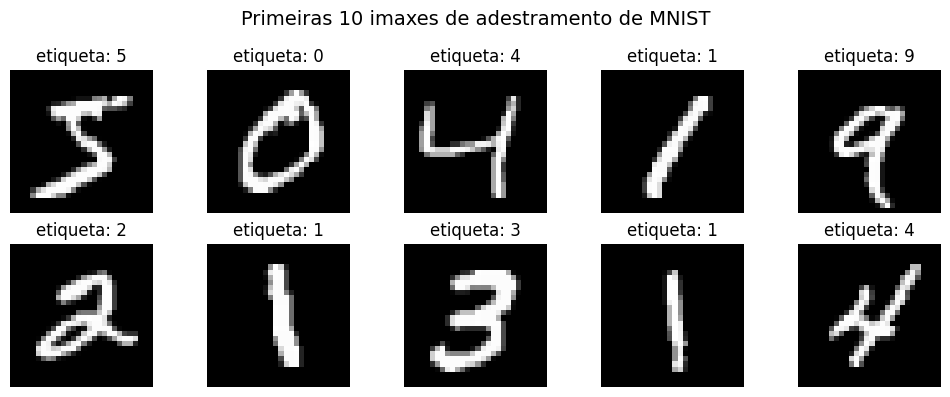

In [15]:
# Collemos as imaxes en bruto (sen normalizar) só para mostralas mellor
raw = datasets.MNIST(root="data", train=True, download=False)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, lbl = raw[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"etiqueta: {lbl}")
    ax.axis("off")
fig.suptitle("Primeiras 10 imaxes de adestramento de MNIST", fontsize=14)
plt.tight_layout()
plt.show()

### DataLoaders (cargadores de datos)

Rara vez lle mostramos á rede unha imaxe de cada vez. En vez diso, agrupamos os exemplos
en **lotes** (aquí, 128 imaxes cada vez). Un `DataLoader` encárgase deste agrupamento por
nós, e baralla os datos de adestramento en cada época para que o modelo non aprenda a orde.

Unha **época** = unha pasada completa por todos os datos de adestramento.

In [16]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

# Ollamos un lote
images, labels = next(iter(train_loader))
print("Un lote de imaxes ten forma:", tuple(images.shape))   # (128, 1, 28, 28)
print("Un lote de etiquetas ten forma:", tuple(labels.shape))

Un lote de imaxes ten forma: (128, 1, 28, 28)
Un lote de etiquetas ten forma: (128,)


## 2. Os bucles de adestramento e avaliación

Adestrar unha rede neuronal é un bucle que repite unha idea sinxela:

1. **Paso cara adiante (forward)** — mostrámoslle á rede un lote de imaxes e deixamos que
   faga predicións.
2. **Perda (loss)** — medimos o erradas que están as predicións (usamos a *entropía
   cruzada*, a perda estándar para clasificación).
3. **Paso cara atrás (backward)** — calculamos canto contribuíu cada peso ao erro
   (*retropropagación*).
4. **Actualización** — axustamos cada peso un pouquiño na dirección que reduce o erro (o
   *optimizador*, aquí **Adam**).

Escribimos estas dúas funcións auxiliares unha soa vez e reutilizámolas para **ambas** as
redes.

In [17]:
def evaluate(model, loader):
    '''Devolve a precisión do modelo nun cargador de datos (fracción de acertos).'''
    model.eval()  # modo avaliación
    correct, total = 0, 0
    with torch.no_grad():  # non fai falta seguir os gradientes ao só medir
        for images, labels in loader:
            outputs = model(images)
            predicted = outputs.argmax(dim=1)  # a clase coa puntuación máis alta
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total


def train(model, epochs=3, lr=1e-3):
    '''Adestra `model` durante un número de épocas e devolve o seu historial.'''
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()  # modo adestramento
        running_loss = 0.0
        start = time.time()

        for images, labels in train_loader:
            optimizer.zero_grad()             # 1. poñer a cero os gradientes
            outputs = model(images)           # 2. paso cara adiante
            loss = F.cross_entropy(outputs, labels)  # 3. canto erramos?
            loss.backward()                   # 4. retropropagación
            optimizer.step()                  # 5. actualizar os pesos
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        acc = evaluate(model, test_loader)
        history["loss"].append(avg_loss)
        history["test_acc"].append(acc)
        print(f"Época {epoch}/{epochs}  |  perda: {avg_loss:.4f}  |  "
              f"precisión na proba: {acc*100:.2f}%  |  {time.time()-start:.1f}s")

    return history

## 3. Modelo 1 — O perceptrón (perceptrón multicapa)

O **perceptrón** é a rede neuronal orixinal, inventada en 1958. Un só perceptrón toma
varias entradas, multiplica cada unha por un **peso**, súmaas, e produce unha saída. Apila
moitos deles en **capas** e obtés un **perceptrón multicapa (MLP)**.

O noso MLP é minúsculo:

```
   784 píxeles  ──►  [ 128 neuronas ]  ──►  [ 10 saídas ]
  (imaxe 28×28)          ReLU            (unha puntuación por díxito)
```

- **Aplanamos** a imaxe 28×28 nunha única fila de 784 números.
- Unha capa oculta de **128 neuronas** aprende combinacións útiles de píxeles.
- **ReLU** (`max(0, x)`) é a *función de activación* — introduce non-linearidade para que a
  rede poida aprender patróns complexos, non só liñas rectas.
- A capa final produce **10 puntuacións**, unha por díxito. A puntuación máis alta é a
  suposición da rede.

Fíxate na debilidade: ao aplanar a imaxe descartamos a estrutura en 2-D — a rede non ten
nin idea de que píxeles son veciños. A CNN da seguinte sección corrixe isto.

### Que fai realmente unha neurona

Antes da rede completa, ampliemos un **só perceptrón (neurona)**. El:

1. toma cada entrada e multiplícaa por un **peso** (`w`) — o peso di canto importa esa
   entrada,
2. **súmaas** todas, máis un **sesgo** (`b`) — un desprazamento constante,
3. pasa o resultado por unha **función de activación** (ReLU) para producir a súa saída.

Nunha liña de matemáticas:  $\;\hat{y} = \text{activación}(w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b)$

O diagrama de abaixo debuxa exactamente isto.

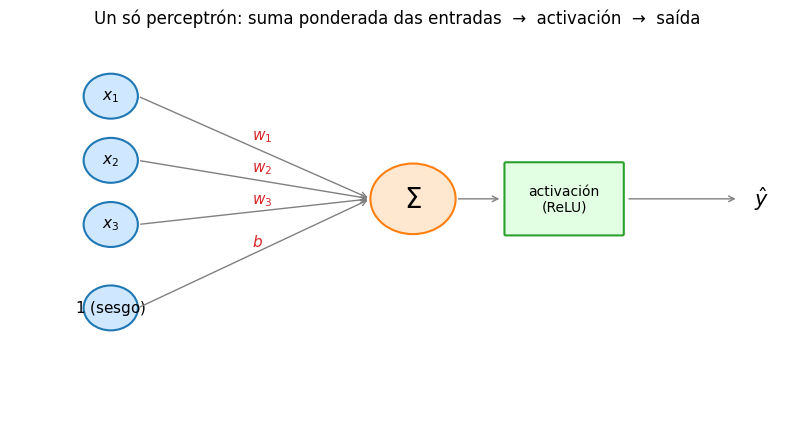

In [18]:
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")

inputs = [(r"$x_1$", 5.0), (r"$x_2$", 4.0), (r"$x_3$", 3.0), (r"$1$ (sesgo)", 1.7)]
weights = [r"$w_1$", r"$w_2$", r"$w_3$", r"$b$"]
sum_xy = (5.2, 3.4)

for (name, y), w in zip(inputs, weights):
    ax.add_patch(Circle((1.3, y), 0.35, fc="#cfe8ff", ec="#1f77b4", lw=1.5, zorder=3))
    ax.text(1.3, y, name, ha="center", va="center", fontsize=11)
    ax.annotate("", xy=(sum_xy[0] - 0.55, sum_xy[1]), xytext=(1.65, y),
                arrowprops=dict(arrowstyle="->", color="gray"))
    ax.text((1.65 + sum_xy[0]) / 2 - 0.3, (y + sum_xy[1]) / 2 + 0.12, w,
            fontsize=11, color="#d62728")

# neurona de suma
ax.add_patch(Circle(sum_xy, 0.55, fc="#ffe8cf", ec="#ff7f0e", lw=1.5, zorder=3))
ax.text(*sum_xy, r"$\Sigma$", ha="center", va="center", fontsize=20)

# caixa de activación
ax.add_patch(FancyBboxPatch((6.4, 2.85), 1.5, 1.1, boxstyle="round,pad=0.02",
                            fc="#e3ffe3", ec="#2ca02c", lw=1.5))
ax.text(7.15, 3.4, "activación\n(ReLU)", ha="center", va="center", fontsize=10)
ax.annotate("", xy=(6.35, 3.4), xytext=(sum_xy[0] + 0.55, sum_xy[1]),
            arrowprops=dict(arrowstyle="->", color="gray"))

# saída
ax.annotate("", xy=(9.4, 3.4), xytext=(7.95, 3.4),
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.text(9.6, 3.4, r"$\hat{y}$", fontsize=15, va="center")

ax.set_title("Un só perceptrón: suma ponderada das entradas  →  activación  →  saída",
             fontsize=12)
plt.show()

**Como *aprende*?** Os pesos e o sesgo comezan sendo aleatorios, así que ao principio a
rede adiviña disparates. O adestramento axusta pouco a pouco cada peso — un pasiño de cada
vez — para que as predicións sexan menos erradas. Ese axuste guíase polo **descenso de
gradiente** e a **retropropagación** (as liñas `loss.backward()` e `optimizer.step()` do
noso bucle de adestramento). Ao longo de miles de exemplos, os pesos aséntanse en valores
que recoñecen díxitos.

Un pouco de historia: o perceptrón foi inventado por **Frank Rosenblatt en 1958**. Un só
pode separar datos cunha liña recta — famosamente *non pode* aprender nin sequera a función
XOR. A solución foi **apilalos en capas** con activacións non lineais, dando o *perceptrón
multicapa* que construímos a continuación.

### O MLP completo como diagrama

Agora conectamos moitas neuronas en **capas**. Cada neurona dunha capa alimenta cada
neurona da seguinte (unha rede *totalmente conectada*). A imaxe de abaixo é esquemática —
as capas reais teñen 784, 128 e 10 neuronas, demasiadas para debuxar, así que cada columna
mostra só unhas poucas.

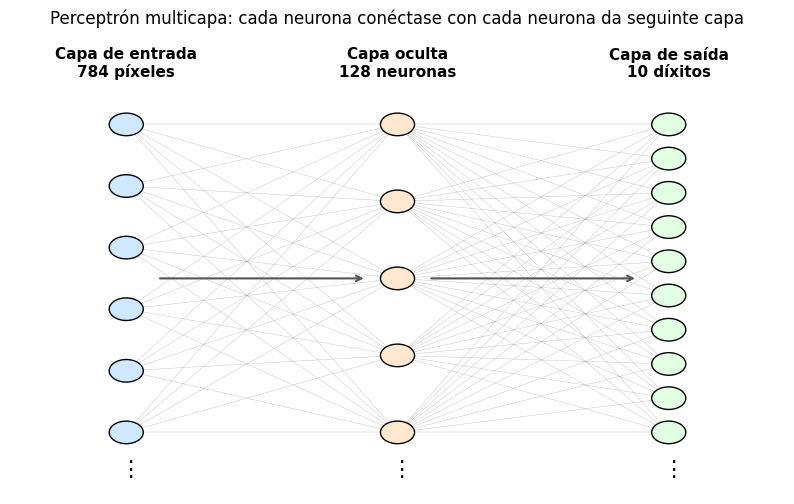

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 9); ax.axis("off")

layer_counts = [6, 5, 10]                       # cantos círculos debuxar
layer_titles = ["Capa de entrada\n784 píxeles",
                "Capa oculta\n128 neuronas",
                "Capa de saída\n10 díxitos"]
xs = [1.5, 5.0, 8.5]
node_colors = ["#cfe8ff", "#ffe8cf", "#e3ffe3"]

positions = []
for n, x in zip(layer_counts, xs):
    ys = np.linspace(1.2, 7.2, n)
    positions.append([(x, y) for y in ys])

# conexións (debúxanse primeiro para que os nodos queden enriba)
for left, right in zip(positions[:-1], positions[1:]):
    for (x1, y1) in left:
        for (x2, y2) in right:
            ax.plot([x1, x2], [y1, y2], color="gray", lw=0.3, alpha=0.5, zorder=1)

# nodos + títulos
for layer, x, title, col in zip(positions, xs, layer_titles, node_colors):
    for (nx, ny) in layer:
        ax.add_patch(Circle((nx, ny), 0.22, fc=col, ec="k", lw=1.0, zorder=3))
    ax.text(x, 8.4, title, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(x, 0.5, r"$\vdots$", ha="center", va="center", fontsize=16)

ax.annotate("", xy=(4.6, 4.2), xytext=(1.9, 4.2),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))
ax.annotate("", xy=(8.1, 4.2), xytext=(5.4, 4.2),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))
ax.set_title("Perceptrón multicapa: cada neurona conéctase con cada neurona da seguinte capa",
             fontsize=12)
plt.show()

In [8]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # capa de entrada -> capa oculta
        self.fc2 = nn.Linear(128, 10)       # capa oculta     -> capa de saída

    def forward(self, x):
        x = x.view(x.size(0), -1)   # aplanar (batch, 1, 28, 28) -> (batch, 784)
        x = F.relu(self.fc1(x))     # capa oculta + activación ReLU
        x = self.fc2(x)             # puntuacións de saída (unha por díxito)
        return x


mlp = MLP()
n_params = sum(p.numel() for p in mlp.parameters())
print(mlp)
print(f"\nParámetros adestrables totais: {n_params:,}")

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Parámetros adestrables totais: 101,770


### Adestrar o MLP

Adestremos durante 3 épocas. Nunha CPU isto leva bastante menos dun minuto. Observa como a
perda **baixa** e a precisión **sobe** — iso é a aprendizaxe ocorrendo en tempo real.

In [9]:
mlp_history = train(mlp, epochs=3)

Época 1/3  |  perda: 0.3054  |  precisión na proba: 94.98%  |  4.5s


Época 2/3  |  perda: 0.1367  |  precisión na proba: 96.39%  |  4.5s


Época 3/3  |  perda: 0.0936  |  precisión na proba: 97.21%  |  4.4s


## 4. Modelo 2 — A rede neuronal convolucional (CNN)

Unha **CNN** está construída para imaxes. En vez de conectar cada píxel con cada neurona,
desliza pequenos **filtros** (aquí 3×3) pola imaxe. Cada filtro aprende a detectar un patrón
local — un bordo, unha esquina, unha curva. As capas iniciais detectan formas simples; as
máis profundas combínanas en formas máis complexas (bucles, trazos, díxitos enteiros).

Dous bloques clave:

- **Convolución** (`Conv2d`) — aplica os filtros aprendibles pola imaxe.
- **Agrupamento máximo (max pooling)** (`max_pool2d`) — reduce a imaxe conservando a
  resposta máis forte en cada rexión 2×2. Isto fai a rede máis rápida e máis robusta fronte
  a pequenos desprazamentos.

A nosa arquitectura:

```
  imaxe 1×28×28
    ─► Conv(1→16) + ReLU + Pool ─►  16×14×14
    ─► Conv(16→32) + ReLU + Pool ─► 32×7×7
    ─► aplanar ─► Linear(→64) + ReLU ─► Linear(→10)
```

Ten un número de parámetros similar ao do MLP, pero como **respecta a estrutura 2-D das
imaxes**, acadará unha precisión notablemente maior.

### Que é unha convolución?

Unha convolución desliza un pequeno **filtro** (unha pequena reixa de pesos — aquí 3×3) pola
imaxe. En cada posición multiplica o filtro polos píxeles de debaixo e súmaos, producindo un
número. Deslízao por toda a imaxe e obtés unha nova imaxe — un **mapa de características** —
que se acende alí onde aparece o patrón do filtro.

O importante: o *mesmo* filtro reutilízase en cada posición (**compartición de parámetros**).
Por iso unha CNN necesita tan poucos pesos e por iso detecta unha forma sen importar *onde*
apareza na imaxe (**invariancia á translación**). O diagrama mostra o filtro 3×3 nunha
posición.

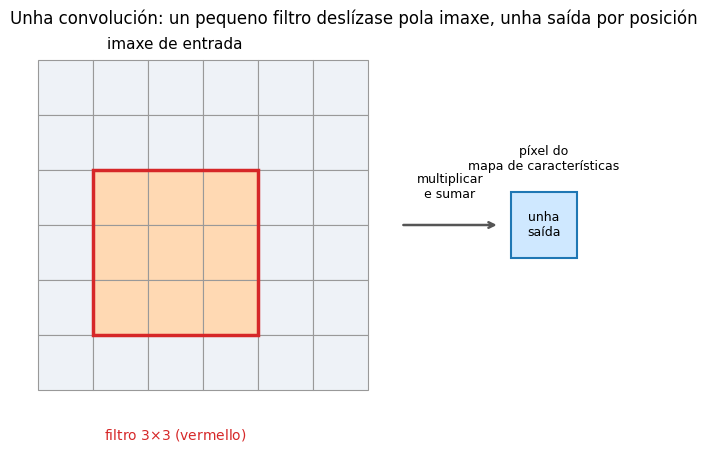

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(-0.5, 12); ax.set_ylim(-0.5, 6.5); ax.axis("off")
ax.set_aspect("equal")

# unha reixa "imaxe" 6x6
grid = 6
for i in range(grid):
    for j in range(grid):
        highlight = (2 <= i <= 4) and (1 <= j <= 3)   # a xanela 3x3
        fc = "#ffd9b3" if highlight else "#eef2f7"
        ax.add_patch(Rectangle((j, grid - 1 - i), 1, 1, fc=fc, ec="#999", lw=0.8))
ax.add_patch(Rectangle((1, grid - 5), 3, 3, fill=False, ec="#d62728", lw=2.5))
ax.text(2.5, grid + 0.2, "imaxe de entrada", ha="center", fontsize=11)
ax.text(2.5, -0.9, r"filtro 3$\times$3 (vermello)", ha="center", fontsize=10, color="#d62728")

# frecha ao único valor de saída
ax.annotate("", xy=(8.4, 3), xytext=(6.6, 3),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.8))
ax.text(7.5, 3.5, "multiplicar\ne sumar", ha="center", fontsize=9)
ax.add_patch(Rectangle((8.6, 2.4), 1.2, 1.2, fc="#cfe8ff", ec="#1f77b4", lw=1.5))
ax.text(9.2, 3.0, "unha\nsaída", ha="center", va="center", fontsize=9)
ax.text(9.2, 4.0, "píxel do\nmapa de características", ha="center", fontsize=9)

ax.set_title("Unha convolución: un pequeno filtro deslízase pola imaxe, unha saída por posición",
             fontsize=12)
plt.show()

### Todo o fluxo da CNN

Apilar convolucións e agrupamentos dá o fluxo de abaixo. Fíxate no patrón: as imaxes fanse
**máis pequenas** (28→14→7, grazas ao agrupamento) pero **máis profundas** (1→16→32 mapas de
características, grazas a máis filtros). A rede troca detalle espacial por características máis
ricas e abstractas, e despois un par de capas totalmente conectadas converten esas
características en 10 puntuacións de díxitos.

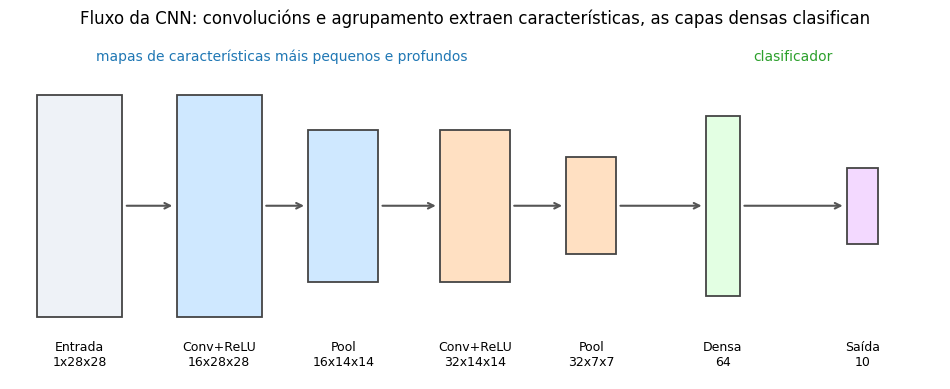

In [11]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5); ax.axis("off")

# (etiqueta, centro-x, medio-ancho, medio-alto, cor)
stages = [
    ("Entrada\n1x28x28",     0.9, 0.55, 1.6, "#eef2f7"),
    ("Conv+ReLU\n16x28x28",  2.7, 0.55, 1.6, "#cfe8ff"),
    ("Pool\n16x14x14",       4.3, 0.45, 1.1, "#cfe8ff"),
    ("Conv+ReLU\n32x14x14",  6.0, 0.45, 1.1, "#ffe0c2"),
    ("Pool\n32x7x7",         7.5, 0.32, 0.7, "#ffe0c2"),
    ("Densa\n64",            9.2, 0.22, 1.3, "#e3ffe3"),
    ("Saída\n10",           11.0, 0.20, 0.55, "#f3d9ff"),
]

prev_right = None
for label, xc, hw, hh, col in stages:
    ax.add_patch(Rectangle((xc - hw, 2.5 - hh), 2 * hw, 2 * hh,
                           fc=col, ec="#444", lw=1.3, zorder=3))
    ax.text(xc, 0.35, label, ha="center", va="center", fontsize=9)
    if prev_right is not None:
        ax.annotate("", xy=(xc - hw - 0.02, 2.5), xytext=(prev_right + 0.02, 2.5),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))
    prev_right = xc + hw

ax.text(3.5, 4.6, "mapas de características máis pequenos e profundos",
        ha="center", fontsize=10, color="#1f77b4")
ax.text(10.1, 4.6, "clasificador", ha="center", fontsize=10, color="#2ca02c")
ax.set_title("Fluxo da CNN: convolucións e agrupamento extraen características, as capas densas clasifican",
             fontsize=12)
plt.show()

### Un pouco máis de contexto sobre as CNN

- **Menos parámetros, estrutura máis intelixente.** Unha capa totalmente conectada nunha
  imaxe 28×28 necesita un peso para *cada* par píxel–neurona. Unha convolución reutiliza un
  pequeno filtro en todas partes, así que aprende moito máis a partir dos mesmos datos.
- **Xerarquía de características.** Os primeiros filtros aprenden cousas simples (bordos,
  esquinas); os máis profundos combínanas en curvas, bucles e finalmente formas de díxitos
  enteiros.
- **O agrupamento (pooling)** conserva a resposta máis forte en cada rexión, facendo a rede
  máis rápida e robusta fronte a pequenos desprazamentos ou tremores na escritura.
- **Impacto no mundo real.** Esta mesma idea — iniciada por *LeNet* de Yann LeCun sobre
  MNIST nos anos 90 — é a antepasada das redes detrás do etiquetado de fotos, a imaxe
  médica, a visión dos coches autónomos e moito máis.

| | MLP (perceptrón) | CNN |
|---|---|---|
| Ve a imaxe como | unha lista plana de 784 píxeles | unha reixa 2-D |
| Operación clave | capas totalmente conectadas | filtros de convolución deslizantes |
| Entende os píxeles veciños? | non | si |
| Robusta fronte a desprazamentos? | non | si (pooling + filtros compartidos) |
| Precisión típica en MNIST | ~97% | ~99% |

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 1  -> 16 mapas de características
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 -> 32 mapas de características
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)  # -> 16 x 14 x 14
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)  # -> 32 x 7 x 7
        x = x.view(x.size(0), -1)                   # aplanar
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


cnn = CNN()
n_params = sum(p.numel() for p in cnn.parameters())
print(cnn)
print(f"\nParámetros adestrables totais: {n_params:,}")

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

Parámetros adestrables totais: 105,866


### Adestrar a CNN

A CNN fai máis cálculo por imaxe, así que cada época é un pouco máis lenta que a do MLP —
pero aínda así só uns poucos segundos nunha CPU.

In [13]:
cnn_history = train(cnn, epochs=3)

Época 1/3  |  perda: 0.2219  |  precisión na proba: 98.14%  |  15.4s


Época 2/3  |  perda: 0.0599  |  precisión na proba: 98.42%  |  15.4s


Época 3/3  |  perda: 0.0429  |  precisión na proba: 98.73%  |  15.4s


## 5. Comparar os dous modelos

Debuxemos como mellorou a precisión na proba de ambas as redes ao longo das épocas.

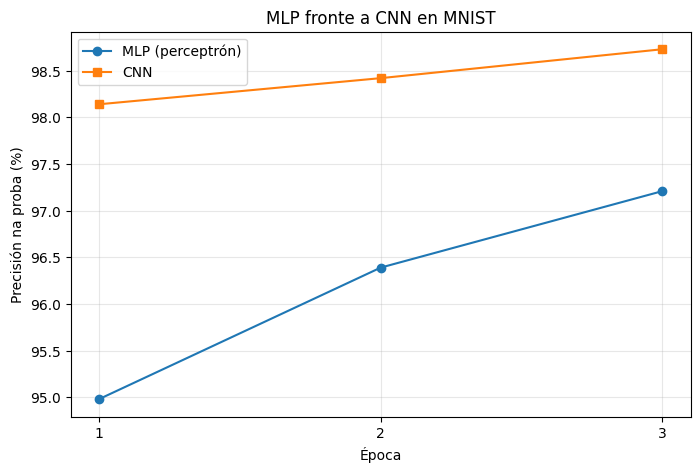

Precisión final do MLP: 97.21%
Precisión final da CNN: 98.73%


In [14]:
epochs = range(1, len(mlp_history["test_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, [a * 100 for a in mlp_history["test_acc"]], "o-", label="MLP (perceptrón)")
plt.plot(epochs, [a * 100 for a in cnn_history["test_acc"]], "s-", label="CNN")
plt.xlabel("Época")
plt.ylabel("Precisión na proba (%)")
plt.title("MLP fronte a CNN en MNIST")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Precisión final do MLP: {mlp_history['test_acc'][-1]*100:.2f}%")
print(f"Precisión final da CNN: {cnn_history['test_acc'][-1]*100:.2f}%")

**Conclusión:** ambos os modelos aprenden a ler díxitos ben, pero a CNN gaña porque a súa
arquitectura está deseñada para imaxes. Esta é unha lección fundamental na aprendizaxe
profunda: *a estrutura axeitada para os teus datos importa tanto como a cantidade de
adestramento.*

## 6. A CNN en acción

Por último, vexamos algunhas predicións reais da CNN adestrada. Os títulos en verde son
correctos, os vermellos son erros. Mesmo cun ~99% de precisión, adoita atoparse algún díxito
realmente complicado que a rede erra — a miúdo algún que un humano tamén dubidaría.

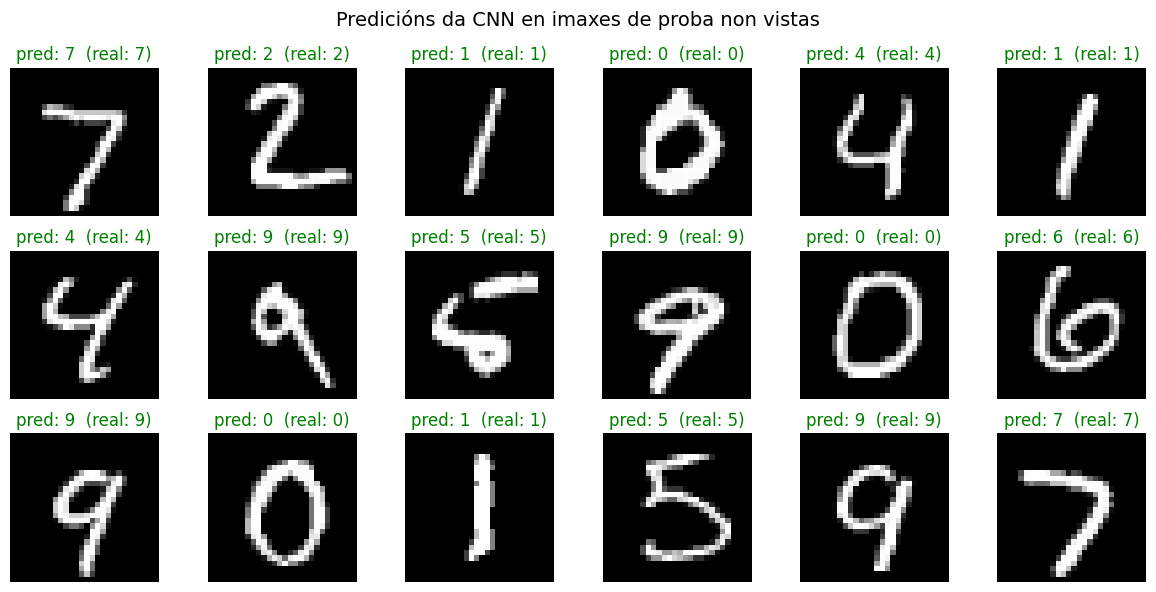

In [15]:
cnn.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = cnn(images).argmax(dim=1)

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # desfacemos a normalización só para mostrar
    img = images[i][0] * 0.3081 + 0.1307
    ax.imshow(img, cmap="gray")
    correct = preds[i].item() == labels[i].item()
    color = "green" if correct else "red"
    ax.set_title(f"pred: {preds[i].item()}  (real: {labels[i].item()})", color=color)
    ax.axis("off")
fig.suptitle("Predicións da CNN en imaxes de proba non vistas", fontsize=14)
plt.tight_layout()
plt.show()

### Onde erra a CNN?

Busquemos por todo o conxunto de proba as imaxes que a CNN errou, e mostremos as primeiras.
Estudar os erros dun modelo é unha das mellores formas de entendelo.

A CNN clasificou mal 127 de 10000 imaxes de proba.


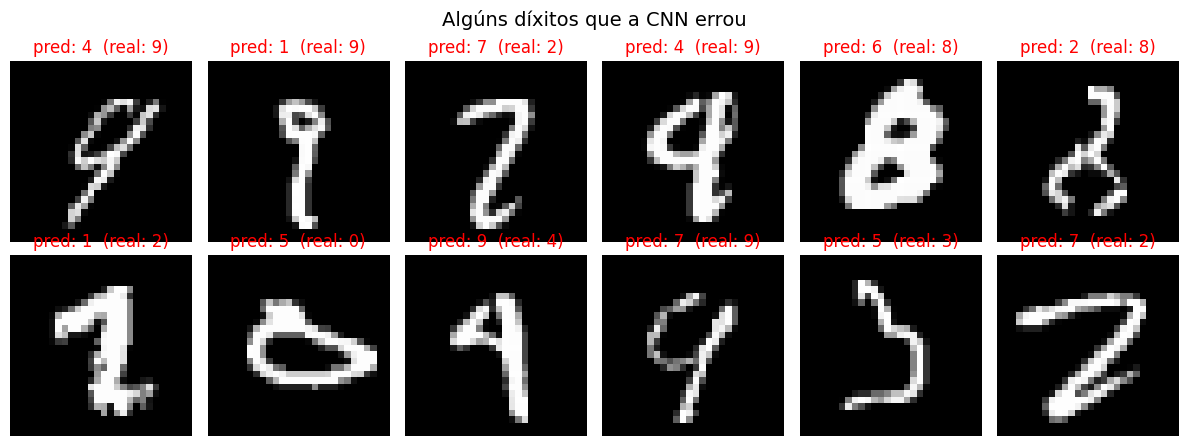

In [16]:
cnn.eval()
wrong_images, wrong_preds, wrong_true = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = cnn(images).argmax(dim=1)
        mask = preds != labels
        for img, p, t in zip(images[mask], preds[mask], labels[mask]):
            wrong_images.append(img)
            wrong_preds.append(p.item())
            wrong_true.append(t.item())

print(f"A CNN clasificou mal {len(wrong_images)} de {len(test_dataset)} imaxes de proba.")

fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
for i, ax in enumerate(axes.flat):
    img = wrong_images[i][0] * 0.3081 + 0.1307
    ax.imshow(img, cmap="gray")
    ax.set_title(f"pred: {wrong_preds[i]}  (real: {wrong_true[i]})", color="red")
    ax.axis("off")
fig.suptitle("Algúns díxitos que a CNN errou", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Resumo e cousas para probar

**O que fixeches neste caderno:**

- Cargaches e visualizaches o conxunto de díxitos manuscritos MNIST.
- Construíches e adestraches un **perceptrón (MLP)** desde cero — acadando ~97% de precisión.
- Construíches e adestraches unha **CNN** — acadando ~99% de precisión.
- Comparáchelos e inspeccionaches os erros da CNN.

**Experimentos para afondar na túa comprensión** (proba a cambiar o código e executalo de
novo):

1. **Adestra máis tempo** — pon `epochs=5` ou `10`. Segue mellorando a precisión, ou
   estáncase?
2. **Cambia o MLP** — fai a capa oculta máis grande (`256`) ou engade unha segunda capa
   oculta. Chega algunha vez un MLP máis grande a superar a CNN?
3. **Cambia a taxa de aprendizaxe** — proba `lr=1e-2` ou `lr=1e-4`. Que pasa se é demasiado
   grande ou demasiado pequena?
4. **Rompe algo a propósito** — quita as activacións `F.relu(...)` do MLP. Por que empeora a
   precisión? (Pista: sen non-linearidade, moitas capas colápsanse nunha soa.)
5. **Sobreaxuste (overfitting)** — adestra a CNN durante 20 épocas e observa se a precisión
   na proba deixa de mellorar aínda que a perda de adestramento siga baixando.

Parabéns — acabas de adestrar redes neuronais reais para recoñecer escritura a man! 🎉